In [1]:
from AutoencoderAPI.recurrentTriplet import recurrentTriplet
from AutoencoderAPI.fileBatch import fileBatch
from AutoencoderAPI.fileBatchtSNE import fileBatchtSNE
from AutoencoderAPI.encoderStack import encoderStack
from AutoencoderAPI.transformer import transformer
from AutoencoderAPI.utils.plot import load_run_results, load_sweep_results, load_run_results_2D
from AutoencoderAPI.sweep import sweep

### Configuration

#### Triplet config

In [2]:
run_config_Triplet = {
'files' : {
        'dataset'                  : "Datasets/SNSPD/Paderborn/data train",
        'path_save'                : 'AutoencoderLog/',
        'input_dimension'          : 30_000, 
        'folder_type'              : 'npy'
        },
'network' : {
        'network_type'             : 'dropout',
        'activation_list'          : ['ReLU', 'ReLU', 'ReLU', 'ReLU', 'ReLU', 'ReLU', 'ReLU'],
        'layer_list'               : [100, 100, 100, 2, 100, 100, 100],
        'CNN_channels'             : [10, 10, 2, 10, 10, 10],
        'layer_type'               : 'Linear',
        'bw_cst'                   : [0.007]
        },
'train' : {
        'optimizer'                : 'Adam',
        'alpha'                    : 0.002,    #0.002
        'epochs_MSE'               : 0,
        'epochs_triplet'           : 5,
        'skip_elements'            : 1,
        'interval'                 : [3250,4250],
        'learning_rate_MSE'        : 1e-4,
        'learning_rate_triplet'    : 1e-6
        }
}

In [3]:
run_config_Triplet = {
'files' : {
        'dataset'                  : "Datasets/TES/NIST train",
        'path_save'                : 'AutoencoderLog/',
        'input_dimension'          : 8192, 
        'folder_type'              : None,
        'dB'                       : [23.5, 24.,  24.5, 25.,  25.5, 26.,  26.5, 27.,  27.5, 28.,  28.5, 29. ]
        },
'network' : {
        'network_type'             : 'CNN',
        'activation_list'          : ['Mish', 'CELU', 'ReLU', 'CELU', 'Mish'],#['ReLU', 'ReLU', 'ReLU', 'ReLU', 'ReLU', 'ReLU', 'ReLU'],#['Hardshrink', 'LeakyReLU', 'PReLU', 'LeakyReLU', 'Hardshrink'],#['Mish', 'CELU', 'Tanh', 'CELU', 'Mish'],
        'layer_list'               : [100, 100, 1, 100, 100],
        'CNN_channels'             : [1, 16, 16, 1, 16, 16, 1],
        'layer_type'               : 'Linear',
        'bw_cst'                   : [0.007]
        },
'train' : {
        'optimizer'                : 'Adam',
        'alpha'                    : 0.1,    #0.002
        'number_cluster'           : 39,
        'epochs_MSE'               : 0,
        'epochs_triplet'           : 10,
        'skip_elements'            : 1,
        'interval'                 : [0,350],
        'learning_rate_MSE'        : 1e-4,
        'learning_rate_triplet'    : 5e-6
        }
}

#### MSE config

In [4]:
run_config_MSE = {
'files' : {
        'dataset'                  : "Datasets/SNSPD/Paderborn/data train",
        'path_save'                : 'AutoencoderLog/',
        'input_dimension'          : 30_000,
        'folder_type'              : 'npy',
        'dB'                       : [23.5, 24.,  24.5, 25.,  25.5, 26.,  26.5, 27.,  27.5, 28.,  28.5, 29. ]
        },
'network' : {
        'network_type'             : 'generic',
        'activation_list'          : ['ReLU', 'ReLU', 'ReLU', 'ReLU', 'ReLU'],#['CELU', 'Mish', 'Tanh', 'Mish', 'CELU'],#['Hardshrink', 'LeakyReLU', 'PReLU', 'LeakyReLU', 'Hardshrink']
        'layer_list'               : [100, 100, 1, 100, 100],
        'layer_type'               : 'Linear'
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'MSELoss',#'MSELoss', 
        'k-fold'                   : 2,
        'batch_number'             : 4,
        'epochs'                   : 3,
        'skip_elements'            : 0,
        'interval'                 : [3250,4250],#[3250,4500],
        'learning_rate'            : 1e-4
        },
'dB' : 15.99
}

In [5]:
run_config_MSE = {
'files' : {
        'dataset'                  : "Datasets/TES/NIST train",
        'path_save'                : 'AutoencoderLog/',
        'input_dimension'          : 8192,
        'folder_type'              : None,
        'dB'                       : [23.5, 24.,  24.5, 25.,  25.5, 26.,  26.5, 27.,  27.5, 28.,  28.5, 29. ]
        },
'network' : {
        'network_type'             : 'CNN',
        'activation_list'          : ['GELU', 'PReLU', 'Sigmoid', 'PReLU', 'GELU'],
        'layer_list'               : [100, 100, 1, 100, 100],
        'CNN_channels'             : [1, 20, 20, 2, 20, 20, 1],
        'layer_type'               : 'Linear'
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'MSELoss', #tSNE#
        'k-fold'                   : 3,
        'batch_number'             : 1,
        'epochs'                   : 5,
        'skip_elements'            : 0,
        'interval'                 : [0,350],
        'learning_rate'            : 8e-05
        }
}

#### Transformer config

In [6]:
run_config_Transformer = {
'files' : {
        'dataset'                  : "Datasets/NIST (250)",
        'path_save'                : 'AutoencoderLog/',
        'input_dimension'          : 8192,
        'folder_type'              : None
        },
'network' : {
        'nhead'                    : 250,
        'dropout'                  : 0.1,
        'sequence_len'             : 10,
        'encoding_dim'             : 2    
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'MSELoss',
        'skip_elements'            : 1,
        'interval'                 : [0,270],
        'epochs'                   : 6,
        'learning_rate'            : 1e-6
        }
}

### CNN config

In [7]:
run_config_CNN = {
'files' : {
        'dataset'                  : "Datasets/TES/NIST train",
        'path_save'                : 'AutoencoderLog/',
        'input_dimension'          : 8192,
        'folder_type'              : None
        },
'network' : {
        'activation_list'          : ['Mish', 'CELU', 'CELU', 'Tanh', 'CELU', 'CELU','Mish'],
        'layer_list'               : [200, 200, 200, 2, 200, 200, 200],
        'layer_type'               : 'Linear'
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'MSELoss',#'tSNE', #MSELoss
        'k-fold'                   : 2,
        'batch_number'             : 1,
        'epochs'                   : 4,
        'skip_elements'            : 1,
        'interval'                 : [0,270],
        'learning_rate'            : 1e-6
        }
}

### Run

In [8]:
#func = recurrentTriplet()
func = fileBatch()
#func = fileBatchtSNE()
#func = transformer()
#func.run(run_config_MSE)

### Sweep

In [9]:
sweep_config = {
    'sweep_name'               : 'grid-search-TES 2D CNN 8',
    'search_param'             : [('train','epochs'),
                                  ('train','learning_rate')],
                               # [('network','activation_possibilty'), # 
                               #  ('network','layer_size_possibility')],   #
    'epochs'                   : [3,4,5,6], #
    'learning_rate'            : [1e-5, 2e-5, 4e-5, 6e-5, 8e-5, 1e-6, 2e-6, 4e-6, 6e-6, 8e-6, 1e-7, 2e-7, 4e-7, 6e-7, 8e-7],
    'alpha'                    : [1e1, 1e0, 1e-1, 1e-2, 1e-3, 1e-4],
    'activation_possibilty'    : ['ReLU', 'Sigmoid', 'CELU', 'Softmax', 'Softmin', 'Hardshrink', 
                                    'LeakyReLU', 'ELU', 'LogSigmoid', 'PReLU', 'GELU', 'SiLU', 
                                    'Mish', 'Softplus', 'Softsign', 'Tanh'],
    'layer_size_possibility'   : [50,100]
}

In [10]:
exp = sweep()
#exp.random_search(run_config_MSE, sweep_config, 20)
#exp.grid_search(run_config_MSE, sweep_config)

### Load Run

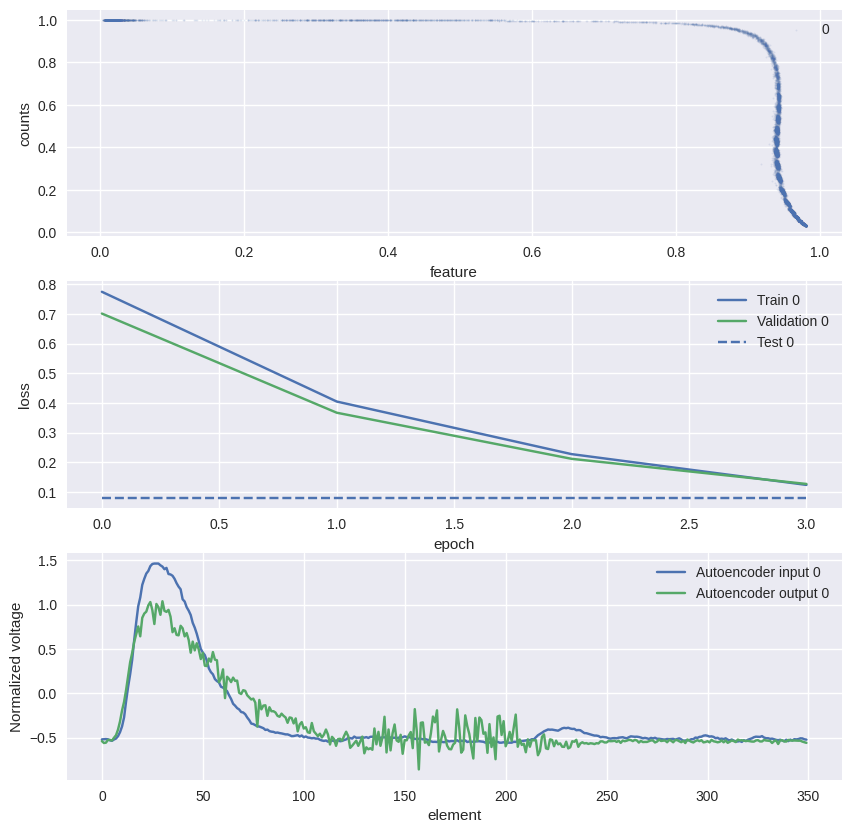

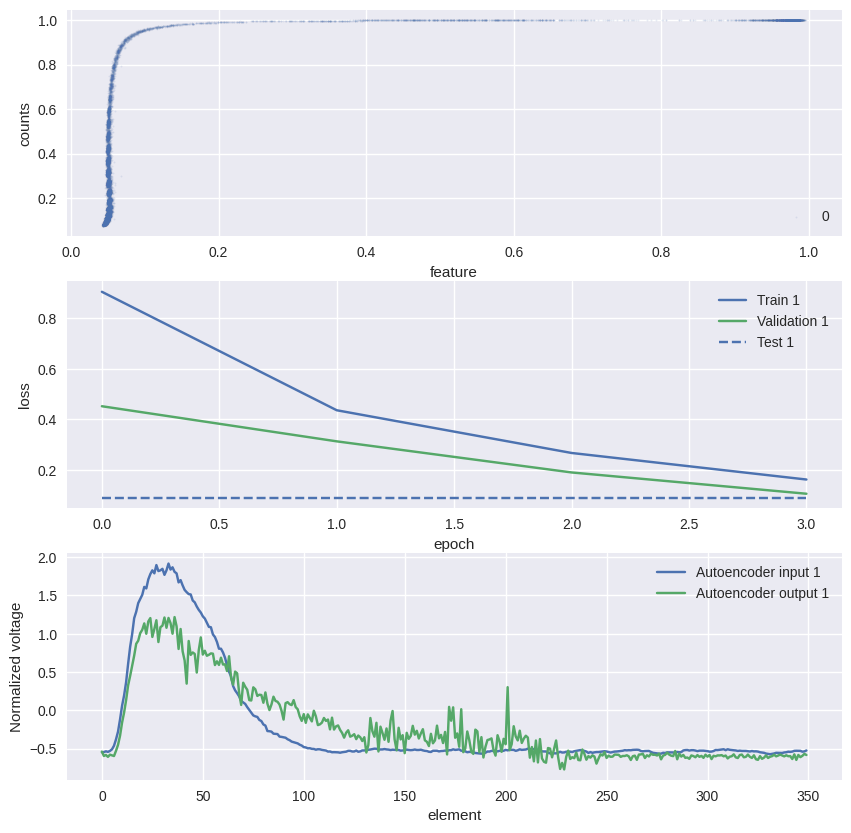

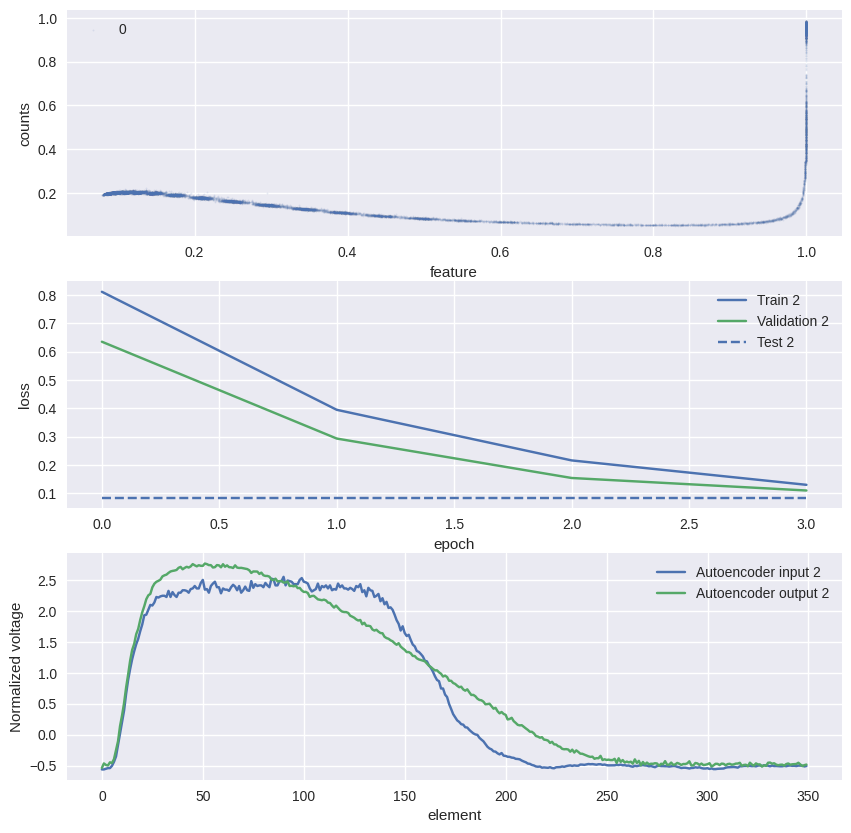

In [11]:
#load_run_results("AutoencoderLog/grid-search-TES 2D CNN 6/run 02", bw=[0.1], clustering=False, print_network=True, print_train=False)
load_run_results_2D("AutoencoderLog/grid-search-TES 2D CNN 6/run 29")#grid-search-TES 2D CNN/run 19 03

### Load Sweep

min : 1.6e-322
file : run 00
epochs :  1.0
learning_rate :  2.564e-321
[0.00307764 0.00159819 0.00155535 0.00135122 0.00170014 0.10199699
 0.02854507 0.01886935 0.01019698 0.00489522 0.79894647 0.59758117
 0.24809174 0.09053976 0.08999131 0.00271663 0.00164718 0.00154589
 0.00156264 0.00113578 0.03033253 0.03533552 0.01003293 0.00630523
 0.00446451 0.63602253 0.39422877 0.11655941 0.12865584 0.05994314
 0.00299722 0.00160923 0.00129515 0.00105386 0.00114256 0.04475276
 0.         0.         0.         0.         0.         0.
 0.         0.         0.        ]


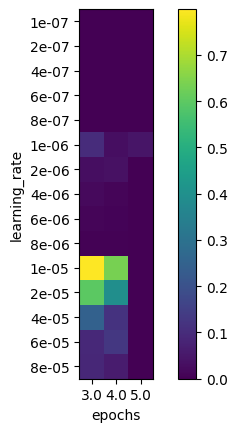

In [13]:
load_sweep_results("grid-search-TES 2D CNN 8", ["epochs","learning_rate"])